In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Load all saved results
with open('results_baseline.pkl', 'rb') as f:
    baseline = pickle.load(f)
with open('results_h1.pkl', 'rb') as f:
    h1 = pickle.load(f)
with open('results_h2.pkl', 'rb') as f:
    h2 = pickle.load(f)
with open('results_h3.pkl', 'rb') as f:
    h3 = pickle.load(f)
with open('results_final.pkl', 'rb') as f:
    final = pickle.load(f)

print("All results loaded.")

All results loaded.


In [6]:
# Comparison table of all experiments

print(f"{'Configuration':<50} {'Best Val Accuracy':>18}")
print("-" * 70)
print(
    f"{'Baseline: frozen ResNet-18, no augmentation':<50} "
    f"{baseline['best_val_acc']:>18.4f}"
)
print(
    f"{'Exp 1: unfrozen ResNet-18':<50} "
    f"{h1['best_val_acc']:>18.4f}"
)
print(
    f"{'Exp 2: unfrozen + data augmentation':<50} "
    f"{h2['best_val_acc']:>18.4f}"
)
print(
    f"{'Exp 3: unfrozen + augmentation + AdamW':<50} "
    f"{h3['best_val_acc']:>18.4f}"
)
print("-" * 70)
print("\nFinal model (Exp 3 configuration, retrained on full trainval)")
print(f"  Overall test accuracy:      {final['test_accuracy']:.4f}")
print(f"  Average per-class accuracy: {final['avg_per_class_accuracy']:.4f}")

Configuration                                       Best Val Accuracy
----------------------------------------------------------------------
Baseline: frozen ResNet-18, no augmentation                    0.4757
Exp 1: unfrozen ResNet-18                                      0.3745
Exp 2: unfrozen + data augmentation                            0.3408
Exp 3: unfrozen + augmentation + AdamW                         0.8689
----------------------------------------------------------------------

Final model (Exp 3 configuration, retrained on full trainval)
  Overall test accuracy:      0.8864
  Average per-class accuracy: 0.8860


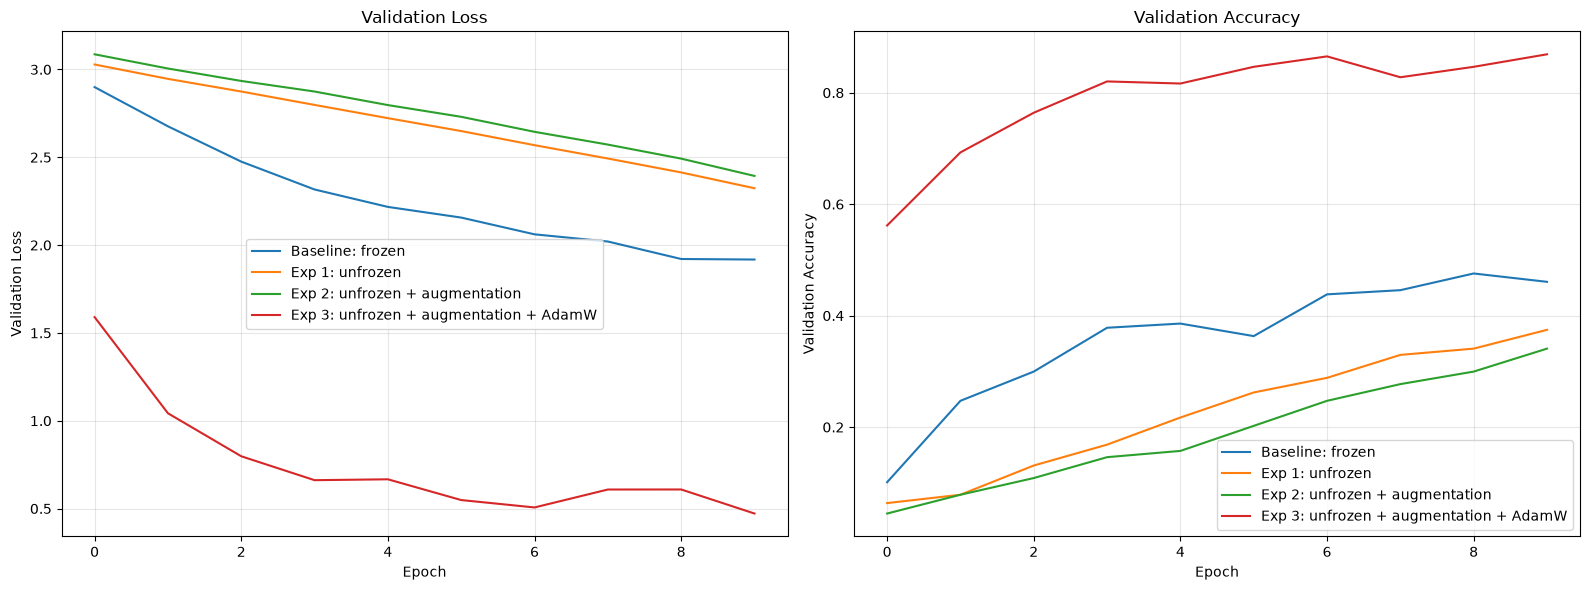

In [7]:
# Learning curves for all experiments on a single graph, as required by the brief

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

runs = [
    (baseline, 'Baseline: frozen'),
    (h1,       'Exp 1: unfrozen'),
    (h2,       'Exp 2: unfrozen + augmentation'),
    (h3,       'Exp 3: unfrozen + augmentation + AdamW'),
]

for run, label in runs:
    axes[0].plot(run['val_loss'], label=label)
    axes[1].plot(run['val_acc'], label=label)

# Validation loss
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation accuracy
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

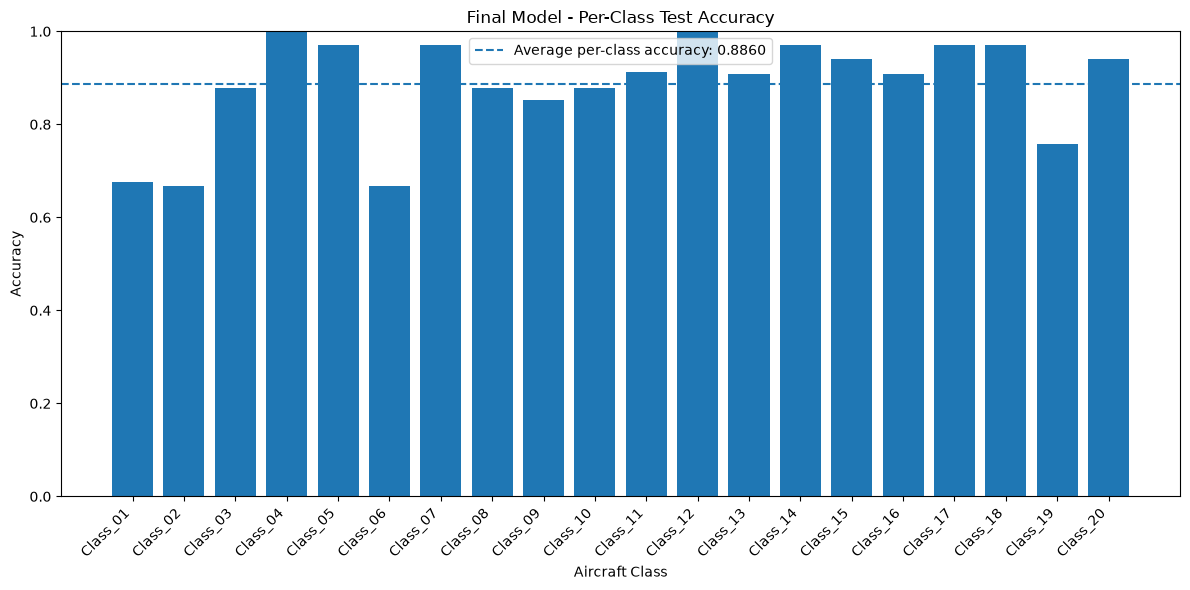

Worst class: Class_02 (0.6667)
Best class: Class_04 (1.0000)


In [8]:
# Per-class test accuracy for the final model

class_names = [f'Class_{i:02d}' for i in range(1, 21)]

class_accuracies = final['class_accuracies']
avg = final['avg_per_class_accuracy']

# Plot per-class accuracy
plt.figure(figsize=(12, 6))

plt.bar(
    range(len(class_accuracies)),
    class_accuracies
)

plt.xticks(
    range(len(class_accuracies)),
    class_names,
    rotation=45,
    ha='right'
)

plt.xlabel('Aircraft Class')
plt.ylabel('Accuracy')
plt.title('Final Model - Per-Class Test Accuracy')

plt.ylim([0, 1])

# Average per-class accuracy
plt.axhline(
    y=avg,
    linestyle='--',
    label=f'Average per-class accuracy: {avg:.4f}'
)

plt.legend()
plt.tight_layout()
plt.show()


# Identify best and worst performing classes
worst_idx = int(np.argmin(class_accuracies))
best_idx = int(np.argmax(class_accuracies))

print(
    f"Worst class: {class_names[worst_idx]} "
    f"({class_accuracies[worst_idx]:.4f})"
)

print(
    f"Best class: {class_names[best_idx]} "
    f"({class_accuracies[best_idx]:.4f})"
)

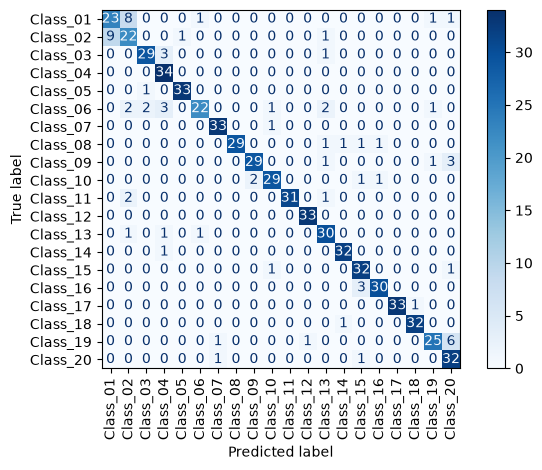

In [9]:

disp = ConfusionMatrixDisplay.from_predictions(final['all_labels'], final['all_predictions'],
                                               display_labels=class_names,
                                               cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.tight_layout()
plt.show()